# Does a good in-distribution fit survive out of distribution?

This notebook builds `Plots/Fig_G1_2col.pdf`, the parity figure of App. I
(Fig. 25, "Limitations of symbolic regression"), read together with Tab. VII,
produced under the default `VARIANT = "plain"` set below. Two smaller variants are
built along the way, a single-model precursor (`Fig_G1.pdf`) and a C4-equivariant
comparison (`Fig_G1_2col_C4.pdf`); neither is included in the built manuscript, and
each is flagged as such where it appears.

### What this notebook does not do

Symbolic regression itself is not run here. Every number and equation quoted in App. I,
the Hall-of-Fame tables, the $R^2_{\mathrm{val}}$ and out-of-distribution $\rho$ columns
of Tab. VII, and the predictions plotted below, come from PySR fitting runs
already recorded under `Plots_data/App_I_data/`. This notebook only reloads their saved output and
plots it. `sr_toolbox.py`, documented in `docs/SYMBOLIC_REGRESSION.md`, is the standalone entry point that actually
runs such a fit, via `tetriscnn.symbolic_regression.run_sr_raw_mode()`.

### The physics question

Symbolic regression is the secondary, post-hoc interpretability route in this project.
The primary one, developed in the main text and used throughout the rest of the
appendices, is a (multi)linear regression of a branch's activation $z_k$ onto its
Boolean-Fourier correlators (`tetriscnn/interpret.py`, main-text Fig. 5). PySR is used
here to ask a narrower, sharper question instead: can a single closed-form equation for
the network's output, built from the bottleneck activations, be extracted that also
holds beyond the training distribution?

The honest answer is no. Across the Hall-of-Fame equations in Tab. VII, no
single expression is simultaneously simple, faithful to the network in distribution,
and robust on all three out-of-distribution probes. Which equation PySR hands back is
largely a consequence of the operator basis and complexity priors set in `SRConfig`
(App. I 1, "Search space and evaluation"), not evidence of a unique underlying form: many
candidates fit comparably well. This is why the appendix leans on the out-of-distribution
metrics, the per-family $R^2$ and the Spearman $\rho$, rather than $R^2_{\mathrm{val}}$
alone, and why this figure plots that out-of-distribution behavior directly rather than
a single scalar goodness-of-fit.

The three out-of-distribution probes, paramagnetic, ferromagnetic and antiferromagnetic,
are idealized, near-zero-temperature analogues of the three phases (each a fixed
representative configuration with four random spin flips), not resamples of the
experimental snapshot distribution. The real data carries projective-measurement noise,
finite-size and edge effects, and non-equilibrium dynamics that these clean synthetic
configurations do not reproduce. An equation that fails on them has already failed the
easier test; the out-of-distribution metrics reported here are a lower bound on how far
its applicability extends, not an estimate of experimental-distribution performance.

### How the plotted equation is chosen

For each SR run, every equation on the PySR Pareto front is scored on the validation
split and on each out-of-distribution family by $R^2$, NRMSE and Spearman $\rho$
(`save_sr_hof_with_avg()` in `tetriscnn/symbolic_regression.py`). Unless a run manually
overrides the choice, the equation whose predictions this notebook plots is the one
with the lowest total Borda-count rank across those leaderboards, ties broken by
$R^2_{\mathrm{val}}$: the same equation marked $\dagger$ in Table `tab:sr_ood`.

### What it reads

Pickled fit results under `Plots_data/App_I_data/models/<run>/<SR-folder>/`, one
`SR_raw_{paramagnetic,ferromagnetic,antiferromagnetic}_sr_plot_data.pkl` per
out-of-distribution family, for four SR runs: the Ising classifier and the Ising
$\Omega$-regression bottleneck, each for the plain and the C4-equivariant network.
Nothing here re-fits or re-derives these files; the notebook only unpickles and plots
them.


In [1]:
import os

from tetriscnn import PAPER_MPLSTYLE

import numpy as np
import pickle
from matplotlib import pyplot as plt
from pathlib import Path

# Paths below (Plots_data/ in, Plots/ out) are relative to the repository root;
# move there so the notebook runs the same from the root or from notebooks/.
os.chdir(next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists()))
Path("Plots/SVG").mkdir(parents=True, exist_ok=True)

## Which trained network populates the figure

`VARIANT` selects the trained front end this notebook reads its SR fits from.
`"plain"` is the standard, non-equivariant TetrisCNN used throughout the main text;
`"C4"` is the weight-tied C4-equivariant variant. **The default, `"plain"`, is what the
manuscript figure is built from.** Switching to `"C4"` reruns every plot below against
the equivariant network instead, for the robustness comparison discussed at the end of
this notebook, not for a manuscript figure.

Both rows are Ising models, matched to two of the three columns of Fig. 20
(App. F 6):

| row | model | Fig. 20 column | bottleneck |
|---|---|---|---|
| top (a, b) | phase classifier | 1 | collapses to a single branch $z[\blacksquare]$ |
| bottom (c, d) | $\Omega$-regression | 3 | rich: several comparable branches, SR-fit at the default `top_k = 3` |

The bottom row is the deliberately richer bottleneck: predicting $\Omega$ from
$Z$-basis snapshots has no single-channel proxy (App. F 6), so SR
has a genuine multi-input target there, and its out-of-distribution failure is the
sharper illustration of "extractor, not discoverer" from the header above. The plain
run keeps branches `[1, 2, 4]` of 10; the C4 run's `smallkernels` set has only 5
branches to begin with (orbit averaging folds the orientation partners together), so it
was trained at a lowered $\lambda_{\max}$ to keep a multi-component bottleneck (see the
`Plots_data/App_I_data` provenance for the exact value).


In [2]:
VARIANT = "plain"          # "plain" | "C4"

_SR = {
    "plain": dict(
        top    = "Plots_data/App_I_data/models/Ising_CLF/SR_clf_sr=single_logit_topk=1",
        bottom = "Plots_data/App_I_data/models/Ising_PDM_Omega/SR_default",
    ),
    "C4": dict(
        top    = "Plots_data/App_I_data/models/Ising_CLF_equivariant/SR_clf_sr=single_logit_topk=1",
        bottom = "Plots_data/App_I_data/models/Ising_PDM_Omega_equivariant/SR_default",
    ),
}[VARIANT]

TOP_SR     = Path(_SR["top"])       # Ising phase classifier   (Fig. 20 col 1)
BOTTOM_SR  = Path(_SR["bottom"])    # Ising Omega-regression    (Fig. 20 col 3)
FIG_SUFFIX = "" if VARIANT == "plain" else f"_{VARIANT}"
print(f"VARIANT = {VARIANT!r}")
print(f"  top    (classifier)      : {TOP_SR}")
print(f"  bottom (Omega-regression): {BOTTOM_SR}")


VARIANT = 'plain'
  top    (classifier)      : Plots_data/App_I_data/models/Ising_CLF/SR_clf_sr=single_logit_topk=1
  bottom (Omega-regression): Plots_data/App_I_data/models/Ising_PDM_Omega/SR_default


## A single-model precursor of the figure

The next cells build an earlier, single-model form of this plot: the Ising phase
classifier alone, without the side-by-side comparison against the $\Omega$-regression
bottleneck. `basepath` is pinned to `TOP_SR`, so only the classifier's SR run is
loaded.

The output, `Plots/Fig_G1{FIG_SUFFIX}.pdf`, is the direct predecessor of the
manuscript figure, superseded by the two-model version built further down, which is the
one the manuscript includes. It is kept here as a
simpler, single-row diagnostic view of the same underlying pickles, not as a
manuscript figure in its own right.


In [3]:
# Single-model parity figure (Fig_G1.pdf, precursor of Fig. 25): the classifier row only.
basepath = TOP_SR


### Reading the SR fit-quality pickles

Each `SR_raw_<family>_sr_plot_data.pkl` is written during the SR run itself, by
`tetriscnn.plots._compute_sr_plot_data()` (invoked from `sr_toolbox.py`), one file per
out-of-distribution family. All three files for a given SR run carry the same six
arrays: `_y_real`, `_y_real_sr` and `error_real` describe the validation
(in-distribution) split and are identical across the three pickles, while `_y_syn`,
`_y_syn_sr` and `error_syn` describe that file's own out-of-distribution probe.
`_y_*` is always the trained network's own output $f_\mathrm{NN}$, `_y_*_sr` the
symbolic surrogate's prediction $f_\mathrm{SR}$ on the same inputs, and `error_*` the
signed residual $f_\mathrm{SR}-f_\mathrm{NN}$ used for the colour scale below.


In [4]:
with open(basepath / "SR_raw_antiferromagnetic_sr_plot_data.pkl", "rb") as f:
    d_afm = pickle.load(f)

In [5]:
with open(basepath / "SR_raw_ferromagnetic_sr_plot_data.pkl", "rb") as f:
    d_ferro = pickle.load(f)

In [6]:
with open(basepath / "SR_raw_paramagnetic_sr_plot_data.pkl", "rb") as f:
    d_para = pickle.load(f)

In [7]:
# --- Plot styling, matching the other appendix figures ---
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
from tetriscnn.colors import COLORS

plt.style.use(PAPER_MPLSTYLE)

SINGLE_WIDTH = 3.4
DOUBLE_WIDTH = 6.80914
golden_ratio = (1 + np.sqrt(5)) / 2

### The parity plot

The plot below stacks two panels sharing one diverging colour scale for the signed
residual: the top panel is the validation parity between $f_\mathrm{NN}$ and
$f_\mathrm{SR}$, the bottom overlays the three out-of-distribution families by marker
shape. The colour scale is clipped to a robust percentile of
$|f_\mathrm{SR}-f_\mathrm{NN}|$ rather than its maximum, so a handful of large
out-of-distribution residuals do not wash out the finer in-distribution structure.
This single-row layout is superseded by the two-row comparison built in the next
section, which is the version that appears in the manuscript.


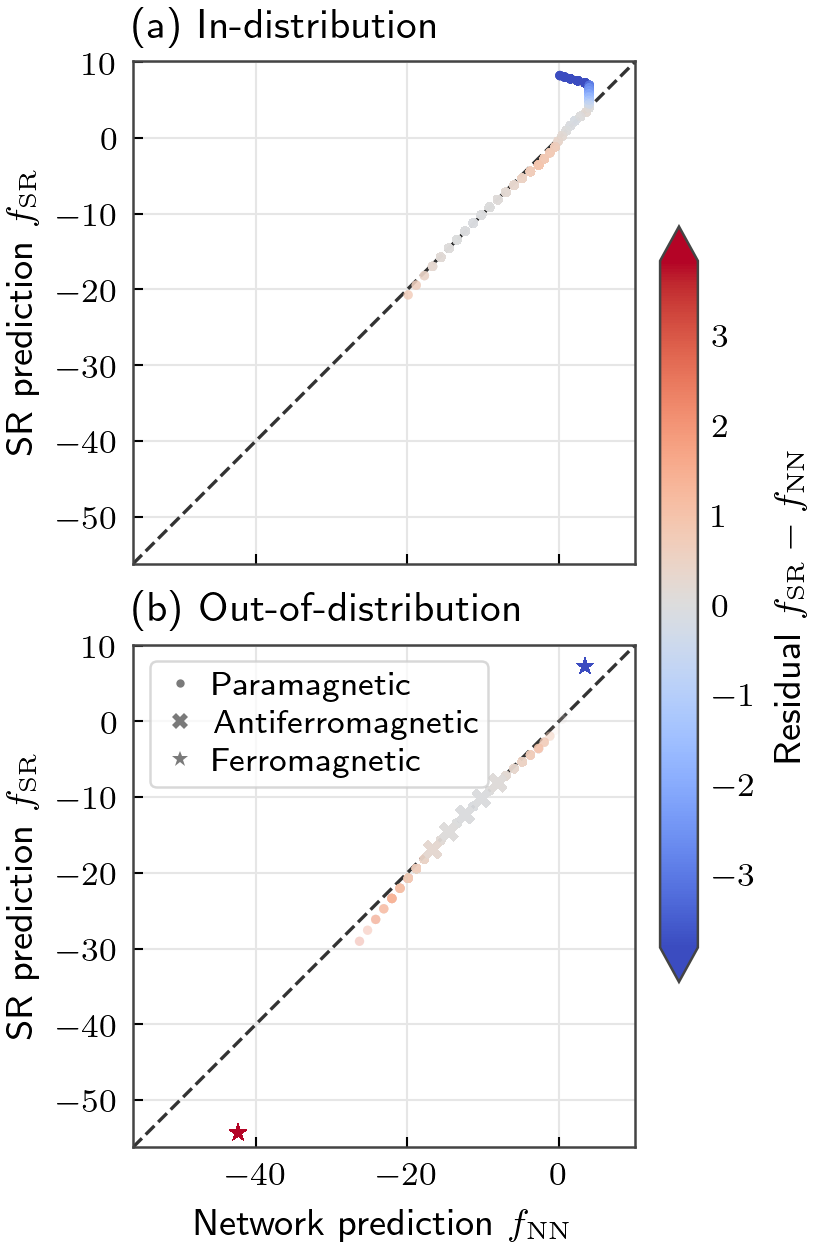

In [8]:
# =============================================================================
#  Parity plot in two stacked panels: in-distribution (validation) points on
#  top, the three out-of-distribution families on the bottom, sharing one
#  diverging colour scale for the signed residual. The in-distribution arrays
#  (`_y_real`, `_y_real_sr`, `error_real`) are identical across the three
#  pickles, so they are taken once from d_para.
# =============================================================================

ood_families = [
    ("Paramagnetic",      d_para,  "."),
    ("Antiferromagnetic", d_afm,   "X"),
    ("Ferromagnetic",     d_ferro, "*"),
]

# In-distribution points (shared across pickles).
ind_x, ind_y, ind_err = d_para["_y_real"], d_para["_y_real_sr"], d_para["error_real"]

x_all = np.concatenate([ind_x] + [d["_y_syn"]    for _, d, _ in ood_families])
y_all = np.concatenate([ind_y] + [d["_y_syn_sr"] for _, d, _ in ood_families])
err_all = np.concatenate([ind_err] + [d["error_syn"] for _, d, _ in ood_families])

# Shared diverging colour scale, centred at zero with a robust (98th-percentile)
# clip so the small in-distribution / para / antiferro residuals stay legible
# while the large ferro residuals saturate the bar ends.
vmax = float(np.percentile(np.abs(err_all), 88))
norm = mpl.colors.Normalize(vmin=-vmax, vmax=vmax)
cmap = "coolwarm"

# Shared square axis range across both panels for a directly comparable diagonal.
lo = float(min(x_all.min(), y_all.min()))
hi = float(max(x_all.max(), y_all.max()))
pad = 0.03 * (hi - lo)

fig, axs = plt.subplots(
    2, 1, figsize=(SINGLE_WIDTH, 2.0 * SINGLE_WIDTH / golden_ratio),
    sharex=True, sharey=True,
)

ms = 20

# --- (a) In-distribution ---
ax = axs[0]
ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad],
        ls="--", lw=0.8, color=COLORS["blackish"], zorder=1)
ax.scatter(ind_x, ind_y, c=ind_err, cmap=cmap, norm=norm,
           marker=".", linewidths=0.0, alpha=0.3, zorder=3, s=ms)
ax.set_ylabel(r"SR prediction $f_\mathrm{SR}$")
ax.set_title("(a) In-distribution", loc="left")

# --- (b) Out-of-distribution ---
ax = axs[1]
ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad],
        ls="--", lw=0.8, color=COLORS["blackish"], zorder=1)
sc = None

for (name, d, marker), alpha in zip(ood_families, [0.1, 1.0, 1.0]):
    sc = ax.scatter(d["_y_syn"], d["_y_syn_sr"],
                    c=d["error_syn"], cmap=cmap, norm=norm,
                    marker=marker, linewidths=0.0, alpha=alpha,
                    label=name, zorder=3, s=ms)
ax.set_xlabel(r"Network prediction $f_\mathrm{NN}$")
ax.set_ylabel(r"SR prediction $f_\mathrm{SR}$")
ax.set_title("(b) Out-of-distribution", loc="left")

# Marker legend (neutral grey) for the OOD families.
handles = [
    plt.Line2D([], [], ls="none", marker=m, ms=4,
               markerfacecolor=COLORS["gray"], markeredgecolor="none", label=n)
    for n, _, m in ood_families
]
ax.legend(handles=handles, loc="upper left", framealpha=0.75)

for ax in axs:
    ax.set_xlim(lo - pad, hi + pad)
    ax.set_ylim(lo - pad, hi + pad)
    ax.set_aspect("equal", adjustable="box")

# One shared colorbar spanning both panels.
cbar = fig.colorbar(sc, ax=axs, extend="both", fraction=0.046, pad=0.03)
cbar.set_label(r"Residual $f_\mathrm{SR} - f_\mathrm{NN}$")

fig.savefig(f"Plots/Fig_G1{FIG_SUFFIX}.pdf")
plt.show()

## The manuscript figure: classifier and regression side by side

This section builds `Plots/Fig_G1_2col.pdf`, the two-row parity figure that
the manuscript includes as Fig. 25. It repeats the loading
pattern introduced above, the same `SR_raw_*_sr_plot_data.pkl` triples with the same
six-array schema, once for `TOP_SR` (top row, classifier) and once for `BOTTOM_SR`
(bottom row, $\Omega$-regression), so both bottlenecks can be drawn on one shared grid
instead of two separate figures.


In [9]:
basepath_top    = TOP_SR       # Ising phase classifier   (Fig. 20 col 1)
basepath_bottom = BOTTOM_SR    # Ising Omega-regression    (Fig. 20 col 3)


In [10]:
with open(basepath_top / "SR_raw_antiferromagnetic_sr_plot_data.pkl", "rb") as f:
    d_afm_top = pickle.load(f)
with open(basepath_bottom / "SR_raw_antiferromagnetic_sr_plot_data.pkl", "rb") as f:
    d_afm_bottom = pickle.load(f)


In [11]:
with open(basepath_top / "SR_raw_ferromagnetic_sr_plot_data.pkl", "rb") as f:
    d_ferro_top = pickle.load(f)
with open(basepath_bottom / "SR_raw_ferromagnetic_sr_plot_data.pkl", "rb") as f:
    d_ferro_bottom = pickle.load(f)


In [12]:
with open(basepath_top / "SR_raw_paramagnetic_sr_plot_data.pkl", "rb") as f:
    d_para_top = pickle.load(f)
with open(basepath_bottom / "SR_raw_paramagnetic_sr_plot_data.pkl", "rb") as f:
    d_para_bottom = pickle.load(f)


In [13]:
# --- Plot styling, matching the other appendix figures ---
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
from tetriscnn.colors import COLORS

plt.style.use(PAPER_MPLSTYLE)

SINGLE_WIDTH = 3.4
DOUBLE_WIDTH = 6.80914
golden_ratio = (1 + np.sqrt(5)) / 2

### Reading the 2x2 grid

Each row repeats the in-distribution/out-of-distribution split of the single-model plot
above: column (a)/(c) is the validation parity, column (b)/(d) the three
out-of-distribution families. Unlike the single-model version, the SR-prediction axis
is clipped to a robust 1st-99th-percentile range rather than the full data span, so
that one badly-extrapolated out-of-distribution point cannot compress the rest of that
row's panel; points beyond the limit still carry their (large) residual colour.

The two equations being scored, one per row, are the Borda-picked equations marked
$\dagger$ in Table `tab:sr_ood`: a cubic in $z[\blacksquare]$ for the classifier row,
and a three-term expression in three two-body branch activations for the
$\Omega$-regression row. Row (a, b) reproduces a near-perfect in-distribution fit
($R^2_{\mathrm{val}}=0.95$) that still degrades on the ferromagnetic probe
($R^2_{\mathrm{ferro}}=0.85$). Row (c, d) is the harder case: the paramagnetic probe's
$R^2$ is $-6.3$, even though, as noted in the header above, the out-of-distribution
predictions stay visibly structured by configuration family rather than scattering
arbitrarily.

Setting `VARIANT = "C4"` at the top of the notebook reruns this entire notebook, both
sections, against the weight-tied C4-equivariant network instead of the plain one used
by the main text, writing `Fig_G1_2col_C4.pdf` (and its single-model counterpart,
`Fig_G1_C4.pdf`). That comparison exists to check that the SR failure mode is not an
artifact of one particular architecture; it is not included in the built manuscript,
so only the `"plain"` output is checked against `final_figures/` below.


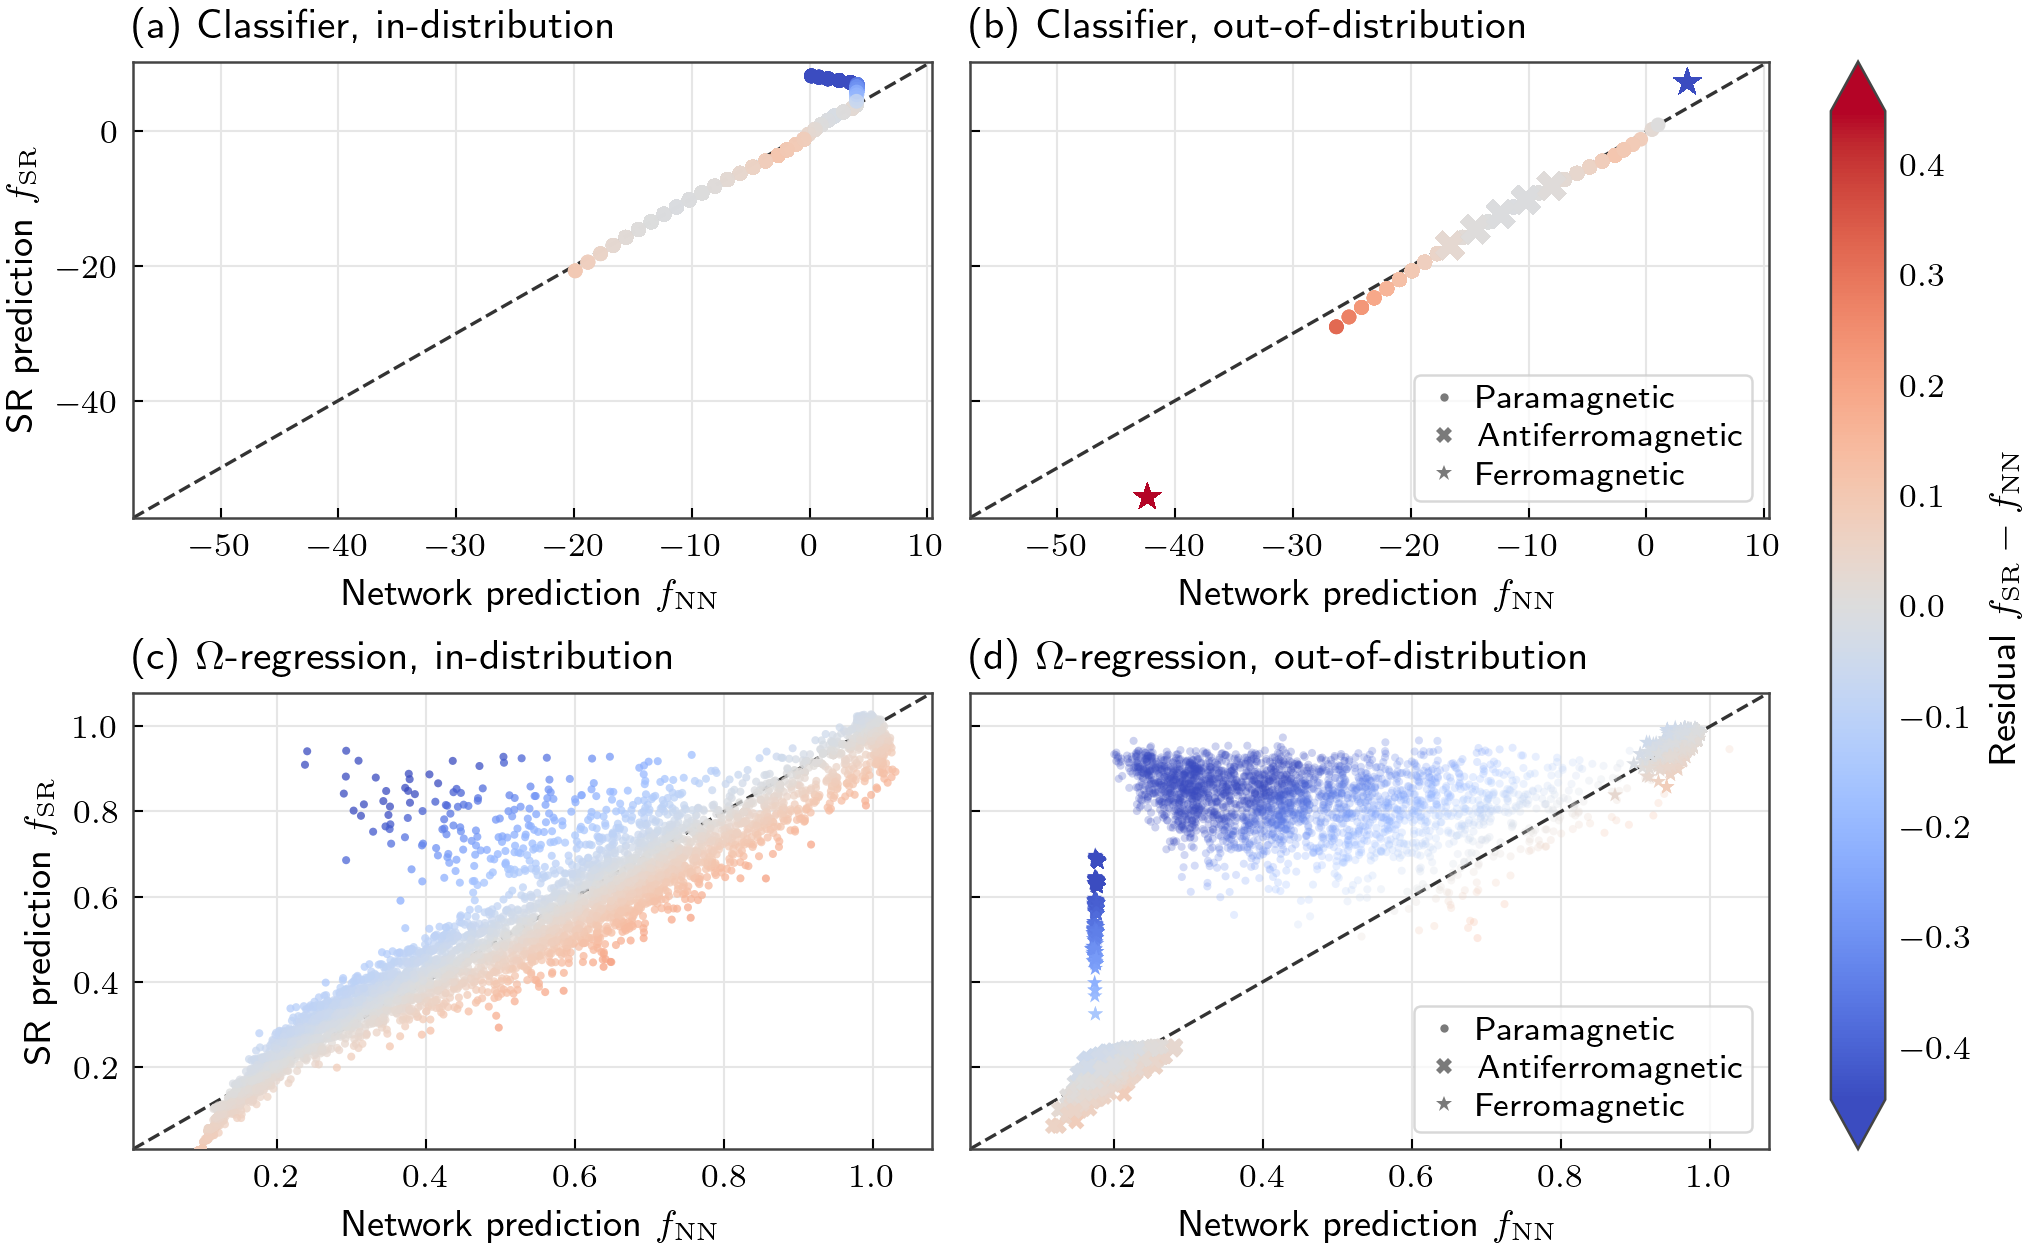

In [14]:
# =============================================================================
#  Parity plot in two stacked panels: in-distribution (validation) points on
#  top, the three out-of-distribution families on the bottom, sharing one
#  diverging colour scale for the signed residual. The in-distribution arrays
#  (`_y_real`, `_y_real_sr`, `error_real`) are identical across the three
#  pickles, so they are taken once from d_para.
# =============================================================================

fig, axs = plt.subplots(
    2, 2, figsize=(DOUBLE_WIDTH, DOUBLE_WIDTH / golden_ratio),
)

for num, (d_para, d_afm, d_ferro) in enumerate([
    (d_para_top, d_afm_top, d_ferro_top), (d_para_bottom, d_afm_bottom, d_ferro_bottom)
    ]):

    row_name = ["Classifier", r"$\Omega$-regression"][num]

    ood_families = [
        ("Paramagnetic",      d_para,  "."),
        ("Antiferromagnetic", d_afm,   "X"),
        ("Ferromagnetic",     d_ferro, "*"),
    ]

    # Per-panel marker styling (row 0 = classifier, row 1 = Omega-regression).
    alphas_tabs = [[1.0, 1.0, 1.0], [0.25, 1.0, 1.0]]
    marker_sizes = [50, 15]

    # In-distribution points (shared across pickles).
    ind_x, ind_y, ind_err = d_para["_y_real"], d_para["_y_real_sr"], d_para["error_real"]

    x_all = np.concatenate([ind_x] + [d["_y_syn"]    for _, d, _ in ood_families])
    y_all = np.concatenate([ind_y] + [d["_y_syn_sr"] for _, d, _ in ood_families])
    err_all = np.concatenate([ind_err] + [d["error_syn"] for _, d, _ in ood_families])

    # Shared diverging colour scale, centred at zero with a robust (98th-percentile)
    # clip so the small in-distribution / para / antiferro residuals stay legible
    # while the large ferro residuals saturate the bar ends.
    vmax = float(np.percentile(np.abs(err_all), 88))
    norm = mpl.colors.Normalize(vmin=-vmax, vmax=vmax)
    cmap = "coolwarm"

    # Shared axis range across both panels for a directly comparable diagonal.
    # Keep the full network-prediction span, but clip the SR-prediction axis to a
    # robust 1-99 percentile (mirrors the vmax percentile clip above) so a single
    # blown-up SR value on an OOD probe cannot squash the whole panel -- points
    # past the limit still colour-code their (large) residual.
    lo = float(min(x_all.min(), np.percentile(y_all, 1)))
    hi = float(max(x_all.max(), np.percentile(y_all, 99)))
    pad = 0.05 * (hi - lo)

    # --- (a) In-distribution ---
    ax = axs[num, 0]
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad],
            ls="--", lw=0.8, color=COLORS["blackish"], zorder=1)
    ax.scatter(ind_x, ind_y, c=ind_err, cmap=cmap, norm=norm,
            marker=".", s=marker_sizes[num], linewidths=0.0, alpha=0.75, zorder=3)
    ax.set_xlabel(r"Network prediction $f_\mathrm{NN}$")
    ax.set_ylabel(r"SR prediction $f_\mathrm{SR}$")
    ax.set_title(f"({['a', 'c'][num]}) {row_name}, in-distribution", loc="left")

    # --- (b) Out-of-distribution ---
    ax = axs[num, 1]
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad],
            ls="--", lw=0.8, color=COLORS["blackish"], zorder=1)
    sc = None
    for (name, d, marker), alpha in zip(ood_families, alphas_tabs[num]):
        sc = ax.scatter(d["_y_syn"], d["_y_syn_sr"],
                        c=d["error_syn"], cmap=cmap, norm=norm,
                        marker=marker, s=marker_sizes[num], linewidths=0.0, alpha=alpha,
                        label=name, zorder=3)
    ax.set_xlabel(r"Network prediction $f_\mathrm{NN}$")
    ax.set_ylabel(r"SR prediction $f_\mathrm{SR}$")
    ax.set_title(f"({['b', 'd'][num]}) {row_name}, out-of-distribution", loc="left")

    # Marker legend (neutral grey) for the OOD families.
    handles = [
        plt.Line2D([], [], ls="none", marker=m, ms=4,
                markerfacecolor=COLORS["gray"], markeredgecolor="none", label=n)
        for n, _, m in ood_families
    ]
    ax.legend(handles=handles, loc="lower right", framealpha=0.75)
    
    # One model - Vertical 

    # One model - Horizontal
    axs[num, 1].set_yticklabels([])
    axs[num, 1].set_ylabel("")

    # for ax in axs[:, num]:
    for ax in axs[num, :]:
        ax.set_xlim(lo - pad, hi + pad)
        ax.set_ylim(lo - pad, hi + pad)


# One shared colorbar spanning both panels.
cbar = fig.colorbar(sc, ax=axs, extend="both", fraction=0.046, pad=0.03)
cbar.set_label(r"Residual $f_\mathrm{SR} - f_\mathrm{NN}$")

fig.savefig(f"Plots/Fig_G1_2col{FIG_SUFFIX}.pdf")
plt.show()